In [44]:
from typing import Annotated, TypedDict, List, Literal
import os
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_community.tools.tavily_search import TavilySearchResults

In [45]:
load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")


In [46]:
class AgentState(MessagesState):
    next_agent:str #which agent goes next
    

In [47]:
@tool
def search_web(query:str) -> str:
    """Search Web for information"""
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content:str) -> str:
    """Write summary of provided content"""
    summary = f"Summary of findsings:\n\n{content[:500]}..."
    return summary

In [48]:
llm = ChatAnthropic(model='claude-sonnet-4-6')
llm

ChatAnthropic(profile={'max_input_tokens': 200000, 'max_output_tokens': 64000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'structured_output': False}, model='claude-sonnet-4-6', max_tokens=64000, anthropic_api_url='https://api.anthropic.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

In [49]:
def researcher_agent(state: AgentState):
    """Researcher agent that searches for info"""
    messages = state["messages"]

    system_msg = SystemMessage(content="You are a researcher assistant, Use the search_web tool to find information about the user's request")

    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    return {
        "messages":[response],
        "next_agent":"writer"
    }

In [50]:
def writer_agent(state:AgentState):
    """Writer agent that creates summaries"""
    messages = state["messages"]
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings")

    # Ensure conversation ends with a user message (Claude doesn't support assistant prefill)
    if messages and isinstance(messages[-1], AIMessage):
        prompt_messages = [system_msg] + messages + [HumanMessage(content="Please write a clear summary of the research findings above.")]
    else:
        prompt_messages = [system_msg] + messages

    response = llm.invoke(prompt_messages)

    return {
        "messages":[response],
        "next_agent":"end"
    }



In [51]:
def route_researcher(state: AgentState):
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "writer"


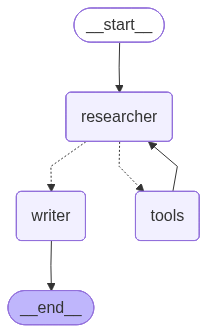

In [52]:
workflow = StateGraph(MessagesState)
tool_node = ToolNode([search_web])


workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("tools", tool_node)



workflow.add_edge(START, "researcher")
workflow.add_conditional_edges("researcher", route_researcher, {"tools": "tools", "writer": "writer"})
workflow.add_edge("tools", "researcher")
workflow.add_edge("writer", END)
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [53]:
config = {"configurable": {"thread_id": "1"}}
result = graph.invoke({"messages": [HumanMessage(content="What are the latest AI trends?")]}, config)
print(result["messages"][-1].content)

# Summary of AI Trends in 2025

## Overview
Artificial intelligence in 2025 is transitioning from experimental technology to a **mainstream, real-world tool**. Industry leaders including Microsoft, IBM, and Google report that AI adoption is accelerating rapidly, with generative AI usage among business leaders rising from **55% to 75%** in just one year.

---

## Key Findings

### Models & Technology
- AI models are becoming **faster, smarter, and more cost-effective**, with advanced reasoning capabilities that mimic human problem-solving
- Smaller, specialized models are proving that **data quality** can be more impactful than sheer model size
- Inference costs are **dropping dramatically**, making AI accessible to a broader range of users and organizations
- Post-training techniques are improving model **safety, accuracy, and alignment** with human needs

### Autonomous AI Agents
- A significant shift is underway from basic chatbots to **fully autonomous, multi-agent AI systems** capa